In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("D:/DLM Research/merged_data.csv")

In [3]:
df

,placenta,MRN,exam_date,delivery_date,pnt_mrn,ancc_hx,still_birth,fund_height,chief_compl,maternal_status,...,hpi,integ_syst,past_med_surg_hstry,under_illness,dur_illness_type,neur_syst,lgs,fet_heart_beat,gus,Institution
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
1,Completed,NaN,NaN,2021-03-04 00:00:00,NaN,NaN,NaN,NaN,NaN,Stable,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
4,NaN,NaN,2021-04-17 00:00:00,NaN,NaN,no,NaN,test,test,NaN,...,test,NaN,test,"none,",NaN,NaN,NaN,NaN,NaN,Yekatit Hospital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646034,NaN,NaN,NaN,NaN,861121.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital
646035,NaN,NaN,NaN,NaN,861122.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital
646036,NaN,NaN,NaN,NaN,861123.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital
646037,NaN,NaN,NaN,NaN,861124.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital


In [4]:
# Drop columns where all values are null
df = df.dropna(axis=1, how='all')

In [5]:
threshold_row = 0.4 * df.shape[1]   # at least 70% non-missing required
df = df.dropna(axis=0, thresh=threshold_row)

In [6]:
df = df.dropna(subset=['delivery_mode'])

In [7]:
df

,placenta,MRN,exam_date,delivery_date,pnt_mrn,ancc_hx,still_birth,fund_height,chief_compl,maternal_status,...,resp_rate,hpi,integ_syst,past_med_surg_hstry,under_illness,neur_syst,lgs,fet_heart_beat,gus,Institution
11,Completed,NaN,2021-03-01 00:00:00,2021-04-02 00:00:00,NaN,unknown,NaN,40 wk si,come for ANC followup with previous cs SCAR,Stable,...,0.0,this is a 31 years old GII and PARA I mother w...,NaN,previvious cs scar,"none,",NaN,NaN,NaN,NaN,Yekatit Hospital
12,Completed,NaN,2021-03-05 00:00:00,2021-04-02 00:00:00,NaN,unknown,NaN,NaN,referred from hc for a case of for 1 previous...,Stable,...,0.0,this is a 31 yrs old GII P1 with UK LMNP . had...,NaN,1`C/S,"none,",NaN,NaN,POSITIVE,NaN,Yekatit Hospital
20,Completed,NaN,2021-03-01 00:00:00,2021-03-08 00:00:00,NaN,no,"[""Fresh""]",NaN,referred from Hc as a case of oligohydraminos,Stable,...,20.0,this is a 35 years old GIII PI AI(spontaneous ...,NaN,none,"none,",NaN,NaN,72bpm,NaN,Yekatit Hospital
23,Completed,NaN,2021-03-01 00:00:00,2021-09-10 00:00:00,NaN,no,NaN,-,Regular ANC follow up,Stable,...,0.0,32 years old G4 P2 (alive via SVD) A1 (spontan...,NaN,None,"none,",NaN,NaN,NaN,NaN,Yekatit Hospital
25,Completed,NaN,2021-03-01 00:00:00,2021-05-08 00:00:00,NaN,no,NaN,NaN,referred from hc for a case of mild polyhydram...,Stable,...,0.0,this is g2p1 mother with GA of 31+5 from 19+2 ...,NaN,None,"none,",NaN,NaN,NaN,NaN,Yekatit Hospital
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645360,Completed,NaN,2026-03-13 00:00:00,2026-03-14 00:00:00,860447.0,NaN,NaN,NaN,NaN,Stable,...,0.0,NaN,No,NONE,NaN,NaN,NaN,NaN,NaN,Zewuditu Hospital
645436,Completed,NaN,2026-03-13 00:00:00,2026-03-15 00:00:00,860523.0,NaN,NaN,34wk,NaN,Stable,...,0.0,NaN,No,Normal,NaN,NaN,NaN,Pos,NaN,Zewuditu Hospital
645667,Completed,NaN,2026-03-16 00:00:00,2026-03-17 00:00:00,860754.0,NaN,NaN,TERM SIZE,NaN,Stable,...,0.0,NaN,No,NO,NaN,NaN,NaN,POS,NaN,Zewuditu Hospital
645713,Completed,NaN,2026-03-16 00:00:00,2026-03-17 00:00:00,860800.0,NaN,NaN,Term,NaN,Stable,...,0.0,NaN,No,Normal,NaN,NaN,NaN,Pos,NaN,Zewuditu Hospital


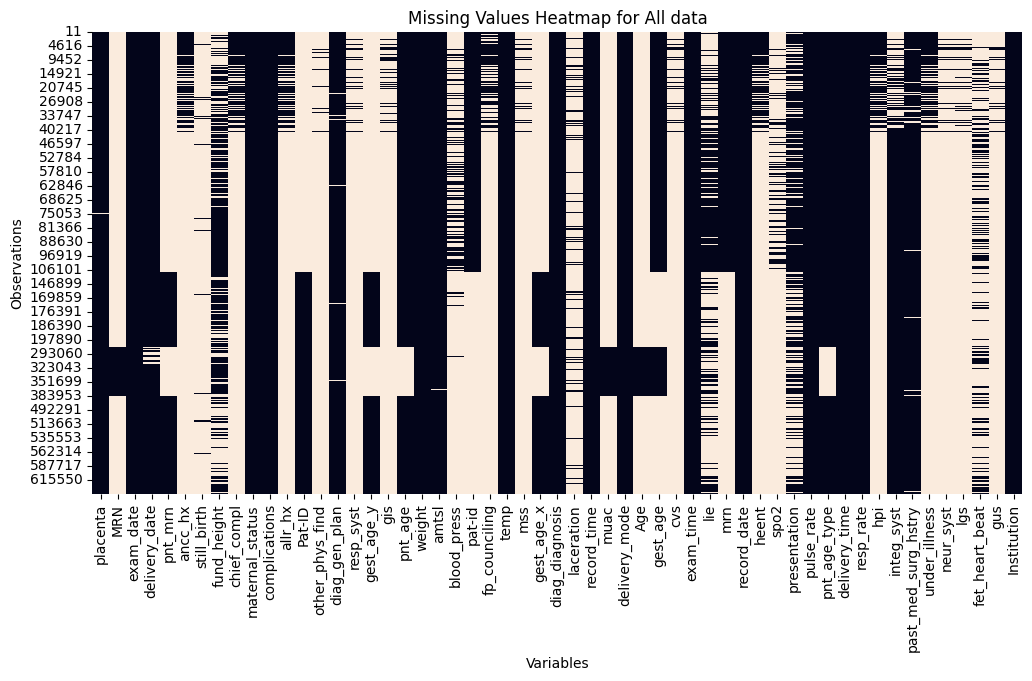

In [8]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap for All data")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

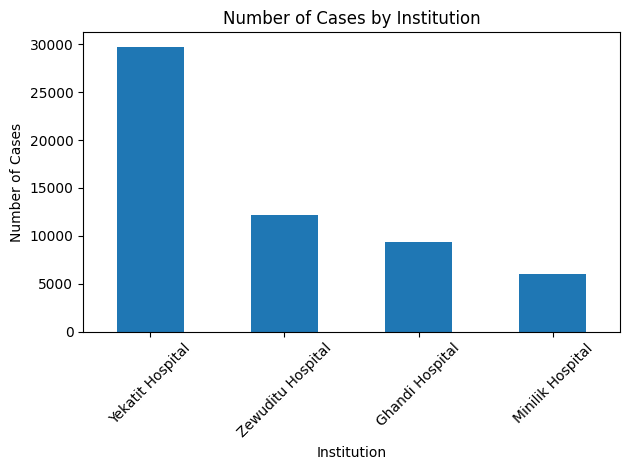

In [9]:
# Count number of cases per institution
counts = df['Institution'].value_counts()

# Plot
counts.plot(kind='bar')

# Labels and title
plt.xlabel('Institution')
plt.ylabel('Number of Cases')
plt.title('Number of Cases by Institution')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57287 entries, 11 to 645819
Data columns (total 55 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   placenta             57228 non-null  object 
 1   MRN                  6026 non-null   float64
 2   exam_date            57287 non-null  object 
 3   delivery_date        56186 non-null  object 
 4   pnt_mrn              21494 non-null  float64
 5   ancc_hx              9543 non-null   object 
 6   still_birth          1368 non-null   object 
 7   fund_height          37268 non-null  object 
 8   chief_compl          9542 non-null   object 
 9   maternal_status      57287 non-null  object 
 10  complications        57287 non-null  object 
 11  allr_hx              9543 non-null   object 
 12  Pat-ID               27528 non-null  float64
 13  other_phys_find      680 non-null    object 
 14  diag_gen_plan        56836 non-null  object 
 15  resp_syst            1984 non-null   ob

In [11]:
# Confirm changes
print(df['complications'].value_counts())

complications
none,                                                              53358
Others specify,                                                     1947
Pre-eclampsia,                                                       920
APH,                                                                 284
PPH,                                                                 262
OL/Prolonged labor,                                                  124
retroviral infection,                                                112
epilepsy,                                                             91
none,Others specify,                                                  57
Eclampsia,                                                            31
Ruptured Uterus,                                                      15
epilepsy,none,                                                        13
OL/Prolonged labor,none,                                              11
PPH,none,                            

In [12]:
# Confirm changes
print(df['delivery_mode'].value_counts())

delivery_mode
Caesarean section                20214
Normal delivery SVD              16916
SVD                              13209
C/S                               5647
Vacuum extraction                  534
Assisted breech delivery           248
Forceps delivery                   212
Assisted Breech delivery           168
Episiotomy                          52
Abdominal surgical deliveries       34
Others                              18
Craniotomy                          12
Abdominal surgical delivery         10
Other                                9
Other Destructive delivery           4
Name: count, dtype: int64


In [13]:
# Work on a safe copy
df = df.copy()

# Standardize text
df['delivery_mode'] = (
    df['delivery_mode']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Initialize new column
df['delivery_mode_clean'] = 'Other'

# 1. Normal Vaginal Delivery
mask_nvd = df['delivery_mode'].str.contains(
    r'\b(svd|normal delivery|spontaneous vaginal delivery)\b', na=False
)
df.loc[mask_nvd, 'delivery_mode_clean'] = 'Normal Vaginal Delivery'

# 2. Cesarean Section
mask_cs = df['delivery_mode'].str.contains(
    r'\b(c/s|caesarean|cesarean|abdominal surgical)\b', na=False
)
df.loc[mask_cs, 'delivery_mode_clean'] = 'Cesarean Section'

# 3. Assisted Vaginal Delivery
mask_avd = df['delivery_mode'].str.contains(
    r'\b(vacuum|Forceps |assisted breech|Breech)\b', na=False
)
df.loc[mask_avd, 'delivery_mode_clean'] = 'Assisted Vaginal Delivery'

# Check result
df['delivery_mode_clean'].value_counts()

delivery_mode_clean
Normal Vaginal Delivery      30125
Cesarean Section             25905
Assisted Vaginal Delivery      950
Other                          307
Name: count, dtype: int64

In [14]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases
df['Long labour'] = df['complications'].str.contains(
    r'Long labour|prolonged labour|prolonged labor|OL|OL',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["Long labour"].value_counts()

Long labour
0    57150
1      137
Name: count, dtype: int64

In [15]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases
df['APH'] = df['complications'].str.contains(
    r'APH',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["APH"].value_counts()

APH
0    56981
1      306
Name: count, dtype: int64

In [16]:
# Split into systolic and diastolic components
df[['bp_systolic', 'bp_diastolic']] = (
    df['blood_press']
    .str.extract(r'(\d+)\s*\/\s*(\d+)')  # Matches "120/80" or "120 / 80"
    .astype(float)  # Convert extracted strings to float
)

In [17]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases (without label encoding)
df['Pre_eclampsia'] = df['complications'].str.contains(
    r'-?pre-eclampsia|pre-?eclampsia|PE|eclampsi|PRE-ECLAMP|Oedema, proteinuria|PRE ECLMPSIA',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

# Display the count of Pre-eclampsia cases
print("Pre-eclampsia cases distribution:")
print(df["Pre_eclampsia"].value_counts())

Pre-eclampsia cases distribution:
Pre_eclampsia
0    54296
1     2991
Name: count, dtype: int64


In [18]:
# Create a working copy of the DataFrame
df = df.copy()

# 1. Create an indicator column for Pre-eclampsia cases
df['eclampsia'] = df['complications'].str.contains(
    r'eclampsia',  # Broad but targeted matching
    case=False, 
    na=False,
    regex=True
).astype(int)

df["eclampsia"].value_counts()

eclampsia
0    56307
1      980
Name: count, dtype: int64

In [19]:
import re
import pandas as pd

def extract_info(text):
    data = {
        'gravida': None,
        'para': None
    }

    if not isinstance(text, str):
        return data

    text = text.lower()

    # Extract gravida and para
    g_p_match = re.search(r'g(\d+)[^\w]*p(\d+)', text)
    if g_p_match:
        data['gravida'] = int(g_p_match.group(1))
        data['para'] = int(g_p_match.group(2))

    return data

# Apply the extraction function to text column (replace 'text_column' with your actual column name)
extracted_data = df['hpi'].apply(extract_info)

# Convert the list of dictionaries to a DataFrame
extracted_df = pd.DataFrame(extracted_data.tolist())

# Add the extracted columns to the original DataFrame
df = pd.concat([df, extracted_df], axis=1)
df.head()

,placenta,MRN,exam_date,delivery_date,pnt_mrn,ancc_hx,still_birth,fund_height,chief_compl,maternal_status,...,Institution,delivery_mode_clean,Long labour,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para
11,Completed,NaN,2021-03-01 00:00:00,2021-04-02 00:00:00,NaN,unknown,NaN,40 wk si,come for ANC followup with previous cs SCAR,Stable,...,Yekatit Hospital,Cesarean Section,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
12,Completed,NaN,2021-03-05 00:00:00,2021-04-02 00:00:00,NaN,unknown,NaN,NaN,referred from hc for a case of for 1 previous...,Stable,...,Yekatit Hospital,Cesarean Section,0.0,0.0,NaN,NaN,0.0,0.0,2.0,1.0
20,Completed,NaN,2021-03-01 00:00:00,2021-03-08 00:00:00,NaN,no,"[""Fresh""]",NaN,referred from Hc as a case of oligohydraminos,Stable,...,Yekatit Hospital,Cesarean Section,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
23,Completed,NaN,2021-03-01 00:00:00,2021-09-10 00:00:00,NaN,no,NaN,-,Regular ANC follow up,Stable,...,Yekatit Hospital,Normal Vaginal Delivery,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN
25,Completed,NaN,2021-03-01 00:00:00,2021-05-08 00:00:00,NaN,no,NaN,NaN,referred from hc for a case of mild polyhydram...,Stable,...,Yekatit Hospital,Cesarean Section,0.0,0.0,NaN,NaN,0.0,0.0,NaN,NaN


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 97384 entries, 11 to 57281
Data columns (total 64 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   placenta             57228 non-null  object 
 1   MRN                  6026 non-null   float64
 2   exam_date            57287 non-null  object 
 3   delivery_date        56186 non-null  object 
 4   pnt_mrn              21494 non-null  float64
 5   ancc_hx              9543 non-null   object 
 6   still_birth          1368 non-null   object 
 7   fund_height          37268 non-null  object 
 8   chief_compl          9542 non-null   object 
 9   maternal_status      57287 non-null  object 
 10  complications        57287 non-null  object 
 11  allr_hx              9543 non-null   object 
 12  Pat-ID               27528 non-null  float64
 13  other_phys_find      680 non-null    object 
 14  diag_gen_plan        56836 non-null  object 
 15  resp_syst            1984 non-null   obj

In [21]:
# Clean feature list
features = [
    'MRN', 'delivery_date', 'still_birth', 'fund_height',
    'pnt_age', 'weight', 'muac',
    'gest_age', 'presentation', 'lie', 'placenta',
    'maternal_status', 'ancc_hx',
    'past_med_surg_hstry',
    'pulse_rate', 'resp_rate', 'temp', 'spo2',
    'fet_heart_beat', 'APH', 'bp_systolic', 'bp_diastolic',
    'Pre_eclampsia', 'eclampsia',
    'gravida', 'para', 'amtsl', 'Long_labour',
    'Institution', 
]

# Optional: standardize column names (recommended)
df.columns = df.columns.str.strip()

# Keep only available columns (prevents crash)
available_features = [col for col in features if col in df.columns]

# Subset dataframe
df = df[available_features + ['delivery_mode_clean']]

In [22]:
df

,MRN,delivery_date,still_birth,fund_height,pnt_age,weight,muac,gest_age,presentation,lie,...,APH,bp_systolic,bp_diastolic,Pre_eclampsia,eclampsia,gravida,para,amtsl,Institution,delivery_mode_clean
11,NaN,2021-04-02 00:00:00,NaN,40 wk si,32.0,0.0,NaN,Term,NaN,NaN,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Oxytocine,Yekatit Hospital,Cesarean Section
12,NaN,2021-04-02 00:00:00,NaN,NaN,32.0,0.0,NaN,Term,NaN,NaN,...,0.0,NaN,NaN,0.0,0.0,2.0,1.0,Oxytocine,Yekatit Hospital,Cesarean Section
20,NaN,2021-03-08 00:00:00,"[""Fresh""]",NaN,28.0,0.0,NaN,Pre-term,NaN,NaN,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Oxytocine,Yekatit Hospital,Cesarean Section
23,NaN,2021-09-10 00:00:00,NaN,-,33.0,0.0,NaN,Term,,NaN,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Oxytocine,Yekatit Hospital,Normal Vaginal Delivery
25,NaN,2021-05-08 00:00:00,NaN,NaN,26.0,0.0,NaN,Post-term,breech,NaN,...,0.0,NaN,NaN,0.0,0.0,NaN,NaN,Oxytocine,Yekatit Hospital,Cesarean Section
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57270,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57271,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57280,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
threshold_row = 0.4 * df.shape[1]   # at least 70% non-missing required
df = df.dropna(axis=0, thresh=threshold_row)

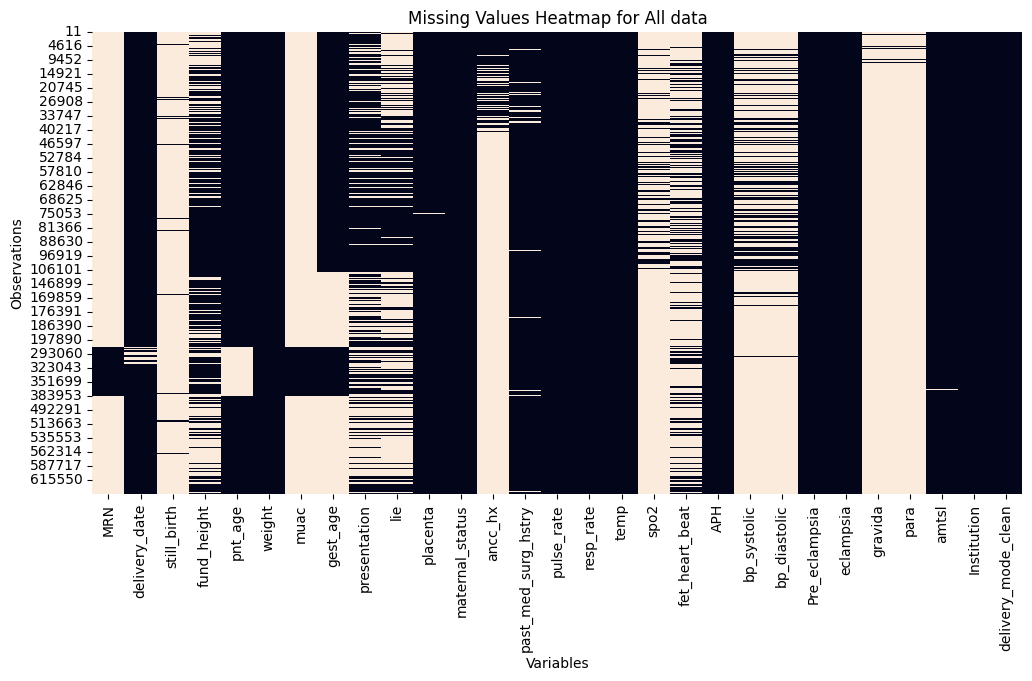

In [24]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap for All data")
plt.xlabel("Variables")
plt.ylabel("Observations")
plt.show()

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 57287 entries, 11 to 645819
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   MRN                  6026 non-null   float64
 1   delivery_date        56186 non-null  object 
 2   still_birth          1368 non-null   object 
 3   fund_height          37268 non-null  object 
 4   pnt_age              51253 non-null  float64
 5   weight               57287 non-null  float64
 6   muac                 6026 non-null   float64
 7   gest_age             35785 non-null  object 
 8   presentation         36408 non-null  object 
 9   lie                  26450 non-null  object 
 10  placenta             57228 non-null  object 
 11  maternal_status      57287 non-null  object 
 12  ancc_hx              9543 non-null   object 
 13  past_med_surg_hstry  55626 non-null  object 
 14  pulse_rate           57287 non-null  float64
 15  resp_rate            57287 non-null  fl

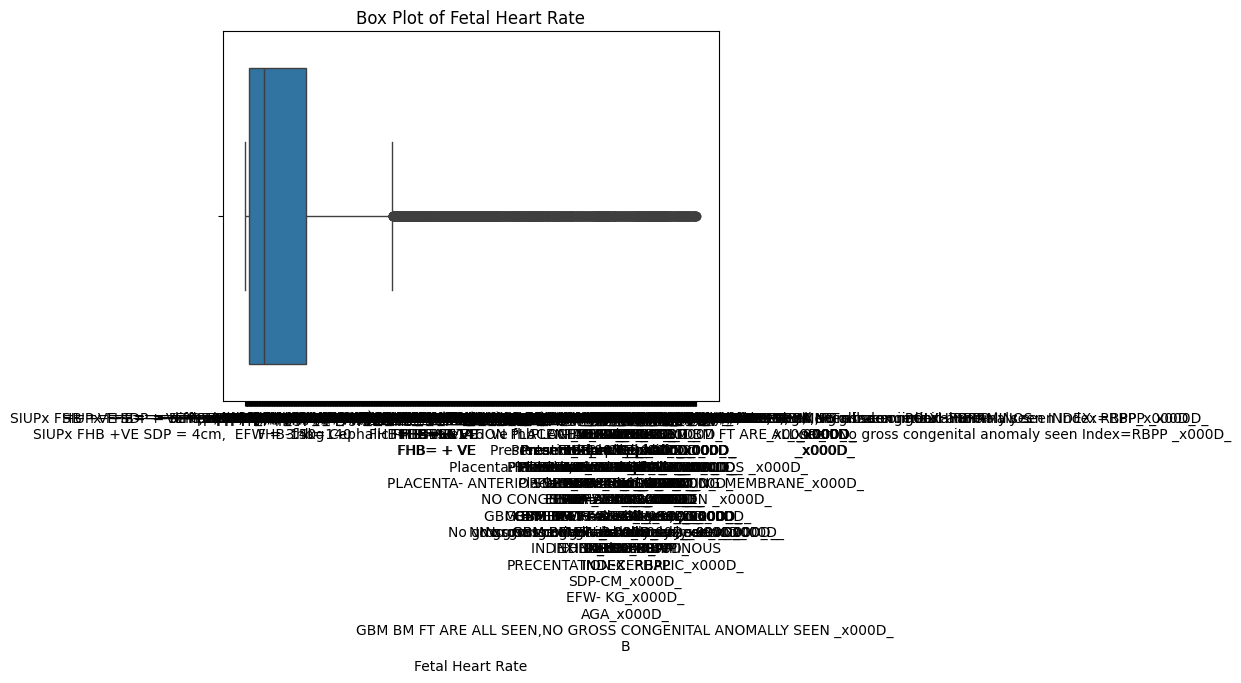

In [28]:
# Step 2: Plot the cleaned column
sns.boxplot(x=df['fet_heart_beat'])
plt.title('Box Plot of Fetal Heart Rate')
plt.xlabel('Fetal Heart Rate')
plt.show()

In [26]:
df.to_csv("D:/DLM Research/processed_data.csv", index=False)